<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2532 entries, 0 to 2531
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2532 non-null   int64  
 1   title         2532 non-null   object 
 2   director      2532 non-null   object 
 3   release_year  2532 non-null   int64  
 4   runtime       2532 non-null   int64  
 5   genre         2532 non-null   object 
 6   rating        2532 non-null   float64
 7   metascore     2532 non-null   int64  
 8   gross(M)      2532 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 178.2+ KB

Missing values: False
Duplicated rows: 0


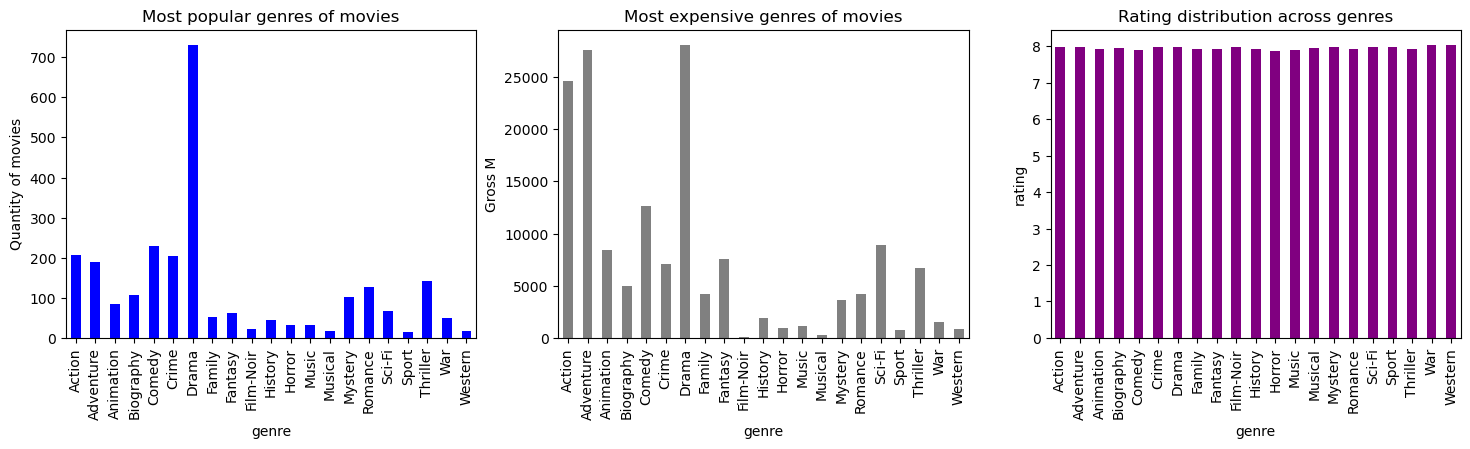

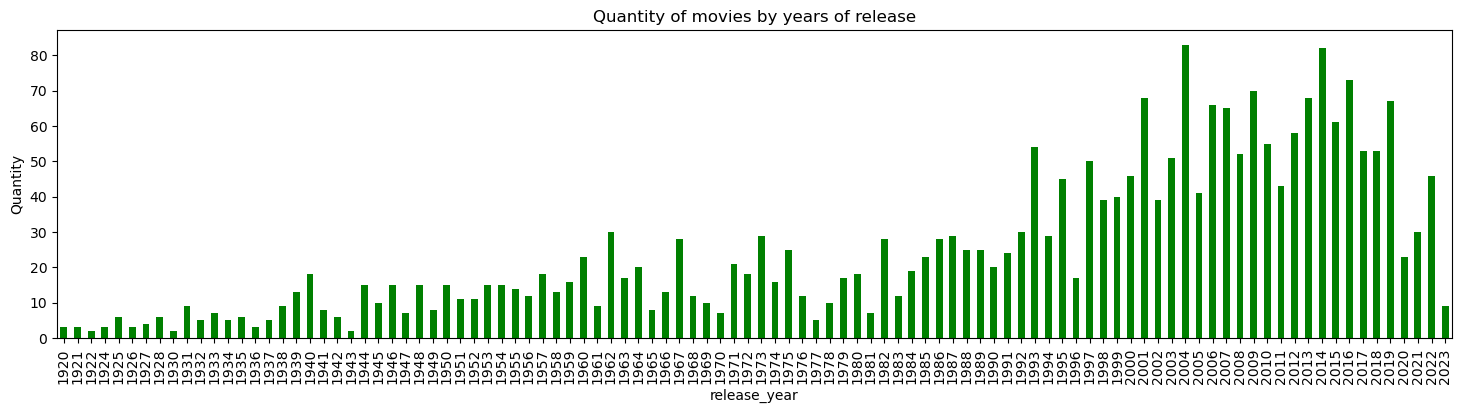


Full list includes 994 movies
The oldest movie belongs to 1920
The newest movie belongs to 2023
Average movies rating = 7.97
Rating values across the data:
0.10    7.7
0.25    7.8
0.50    7.9
0.75    8.1
Name: rating, dtype: float64


In [201]:
#import of libraries
import pandas as pd
import matplotlib.pyplot as plt

#1. Download dataset
data=pd.read_csv("imdb_clean.csv")
df=pd.DataFrame(data)

#Main info
df.info()
df.head()

#2. Cleaning data, transforming data types
print ( f"\nMissing values: {df.isna().values.any()}")
print(f"Duplicated rows: {df.duplicated().sum()}")
df["release_year"]=pd.to_datetime(df["release_year"], format="%Y").dt.year

#3. Main statistics
total_qty=df["title"].nunique() #Total number of movies in the list
rating_av=round(df["rating"].mean(),2) #Average rating of movies
q_10_25_50_75=df["rating"].quantile([0.1, 0.25, 0.5, 0.75]) #Points below which certain percentage of data falls
early=df["release_year"].min() #Oldest year of movies release
late=df["release_year"].max() #Newest movies by year of release

#4. Group movies by year of release, genres
by_years=df.groupby("release_year")["title"].size()
by_genres_M=df.groupby("genre")["gross(M)"].sum()
by_genres_Q=df.groupby("genre")["title"].count()
by_genres_R=df.groupby("genre")["rating"].mean()

#5. Visualisations
plt.figure(figsize=(18, 4))

#Most popular genres
plt.subplot(1,3,1)
by_genres_Q.plot(kind="bar", color="blue")
plt.title("Most popular genres of movies")
plt.ylabel("Quantity of movies")
#Distribution of gross for expensive genres
plt.subplot(1,3,2)
by_genres_M.plot(kind="bar", color="grey")
plt.title("Most expensive genres of movies")
plt.ylabel("Gross M")
#Frequency of movies rating
plt.subplot(1,3,3)
by_genres_R.plot(kind="bar",color="purple")
plt.title("Rating distribution across genres")
plt.ylabel("Rating")
plt.show()

#Dynamic of movies quantity by years
plt.figure(figsize=(18,4))
by_years.plot(kind="bar",color ="green")
plt.ylabel("Quantity")
plt.title("Quantity of movies by years of release")
plt.show()

#6. Outcomes
print(f"\nFull list includes {total_qty} movies")
print("The oldest movie belongs to", early)
print("The newest movie belongs to", late)
print("Average movies rating =", rating_av)
print(f"Rating values across the data:\n{q_10_25_50_75}")

        